In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow keras nltk wordcloud

In [ ]:
import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
from sklearn.cluster import KMeans

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
from wordcloud import WordCloud

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

True

In [ ]:
CSV_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df_raw = pd.read_csv(CSV_PATH)
print(f"Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

print("SQL & DATA MANAGEMENT")

DB_PATH = "telecom_churn.db"
conn = sqlite3.connect(DB_PATH)
df_raw.to_sql("customers", conn, if_exists="replace", index=False)
print(f" Data stored in SQLite database: {DB_PATH}")

query_churn_by_contract = """
SELECT Contract,
       COUNT(*) AS total_customers,
       SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned,
       ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2)
           AS churn_rate_pct
FROM customers
GROUP BY Contract
ORDER BY churn_rate_pct DESC;
"""
df_sql = pd.read_sql(query_churn_by_contract, conn)
print("\n SQL Query — Churn Rate by Contract Type:")
print(df_sql.to_string(index=False))

query_avg_charges = """
SELECT Churn,
       ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
       ROUND(AVG(tenure), 1)         AS avg_tenure_months
FROM customers
GROUP BY Churn;
"""
df_charges = pd.read_sql(query_avg_charges, conn)
print("\n SQL Query — Average Charges & Tenure by Churn:")
print(df_charges.to_string(index=False))

conn.close()



Dataset loaded: 7043 rows × 21 columns
SQL & DATA MANAGEMENT
 Data stored in SQLite database: telecom_churn.db

 SQL Query — Churn Rate by Contract Type:
      Contract  total_customers  churned  churn_rate_pct
Month-to-month             3875     1655           42.71
      One year             1473      166           11.27
      Two year             1695       48            2.83

 SQL Query — Average Charges & Tenure by Churn:
Churn  avg_monthly  avg_tenure_months
   No        61.27               37.6
  Yes        74.44               18.0


EDA & DESCRIPTIVE ANALYTICS

 Overall Churn Rate: 26.5%
 Average CLV: $7,771
 Average CLV (Churned): $8,933
 Average CLV (Retained): $7,352


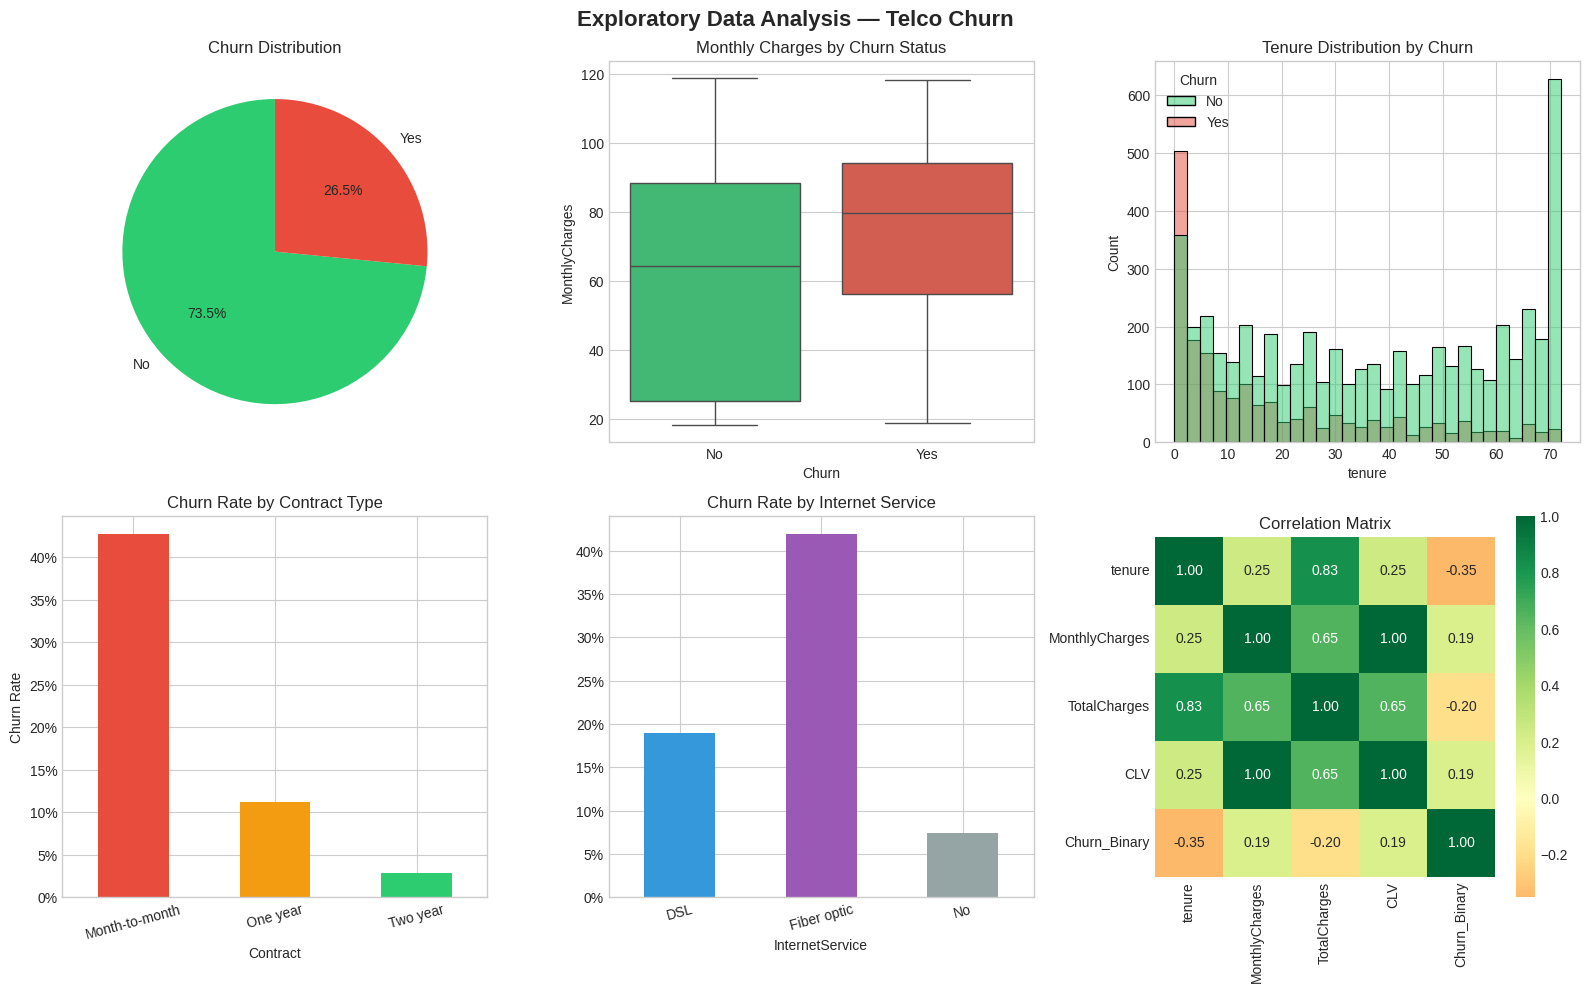

EDA plots saved: 01_eda_overview.png


In [ ]:
print("EDA & DESCRIPTIVE ANALYTICS")
df = df_raw.copy()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

df["Churn_Binary"] = (df["Churn"] == "Yes").astype(int)
churn_rate = df["Churn_Binary"].mean() * 100
print(f"\n Overall Churn Rate: {churn_rate:.1f}%")

DISCOUNT_RATE = 0.1  # 10% annual
df["CLV"] = df["MonthlyCharges"] * (1 / (DISCOUNT_RATE / 12))
print(f" Average CLV: ${df['CLV'].mean():,.0f}")
print(f" Average CLV (Churned): ${df.loc[df['Churn_Binary']==1,'CLV'].mean():,.0f}")
print(f" Average CLV (Retained): ${df.loc[df['Churn_Binary']==0,'CLV'].mean():,.0f}")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Exploratory Data Analysis — Telco Churn", fontsize=16, fontweight="bold")


churn_counts = df["Churn"].value_counts()
axes[0, 0].pie(churn_counts, labels=churn_counts.index, autopct="%1.1f%%",
               colors=["#2ecc71", "#e74c3c"], startangle=90)
axes[0, 0].set_title("Churn Distribution")


sns.boxplot(x="Churn", y="MonthlyCharges", data=df, ax=axes[0, 1],
            palette={"No": "#2ecc71", "Yes": "#e74c3c"})
axes[0, 1].set_title("Monthly Charges by Churn Status")


sns.histplot(data=df, x="tenure", hue="Churn", bins=30, ax=axes[0, 2],
             palette={"No": "#2ecc71", "Yes": "#e74c3c"})
axes[0, 2].set_title("Tenure Distribution by Churn")


ct = df.groupby("Contract")["Churn_Binary"].mean().sort_values(ascending=False)
ct.plot(kind="bar", ax=axes[1, 0], color=["#e74c3c", "#f39c12", "#2ecc71"], rot=15)
axes[1, 0].set_title("Churn Rate by Contract Type")
axes[1, 0].set_ylabel("Churn Rate")
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))


ct2 = df.groupby("InternetService")["Churn_Binary"].mean()
ct2.plot(kind="bar", ax=axes[1, 1], color=["#3498db", "#9b59b6", "#95a5a6"], rot=15)
axes[1, 1].set_title("Churn Rate by Internet Service")
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))


num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "CLV", "Churn_Binary"]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            ax=axes[1, 2], center=0, square=True)
axes[1, 2].set_title("Correlation Matrix")

plt.tight_layout()
plt.savefig("01_eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA plots saved: 01_eda_overview.png")


In [ ]:
print("DATA PRE-PROCESSING FOR MACHINE LEARNING")

drop_cols = ["customerID", "Churn", "Churn_Binary", "CLV", "TotalCharges"]
feature_df = df.drop(columns=drop_cols)

le = LabelEncoder()
cat_cols = feature_df.select_dtypes(include="object").columns
for col in cat_cols:
    feature_df[col] = le.fit_transform(feature_df[col].astype(str))

scaler = StandardScaler()
X = scaler.fit_transform(feature_df)
y = df["Churn_Binary"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f" Train set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")
print(f" Features used: {X_train.shape[1]}")





DATA PRE-PROCESSING FOR MACHINE LEARNING
 Train set: 5634 samples | Test set: 1409 samples
 Features used: 18


CLASSIFICATION — LOGISTIC REGRESSION & DECISION TREE

 Logistic Regression
              precision    recall  f1-score   support

    Retained       0.84      0.89      0.87      1035
     Churned       0.65      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

AUC-ROC: 0.8378

 Decision Tree
              precision    recall  f1-score   support

    Retained       0.86      0.84      0.85      1035
     Churned       0.58      0.62      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.78      0.78      1409

AUC-ROC: 0.8257


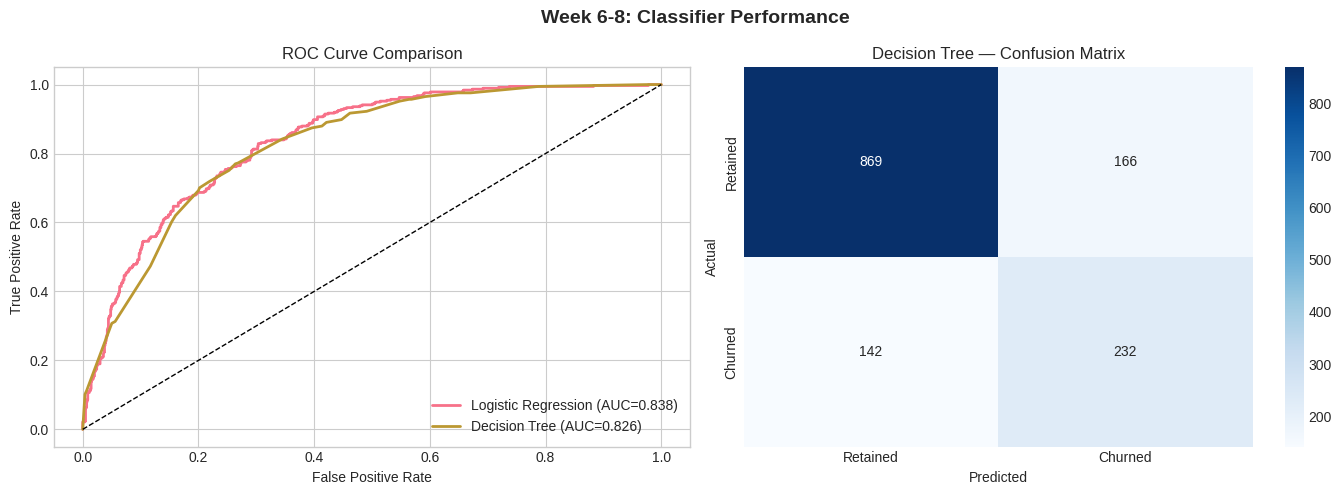

Classification plots saved: 02_classification_results.png


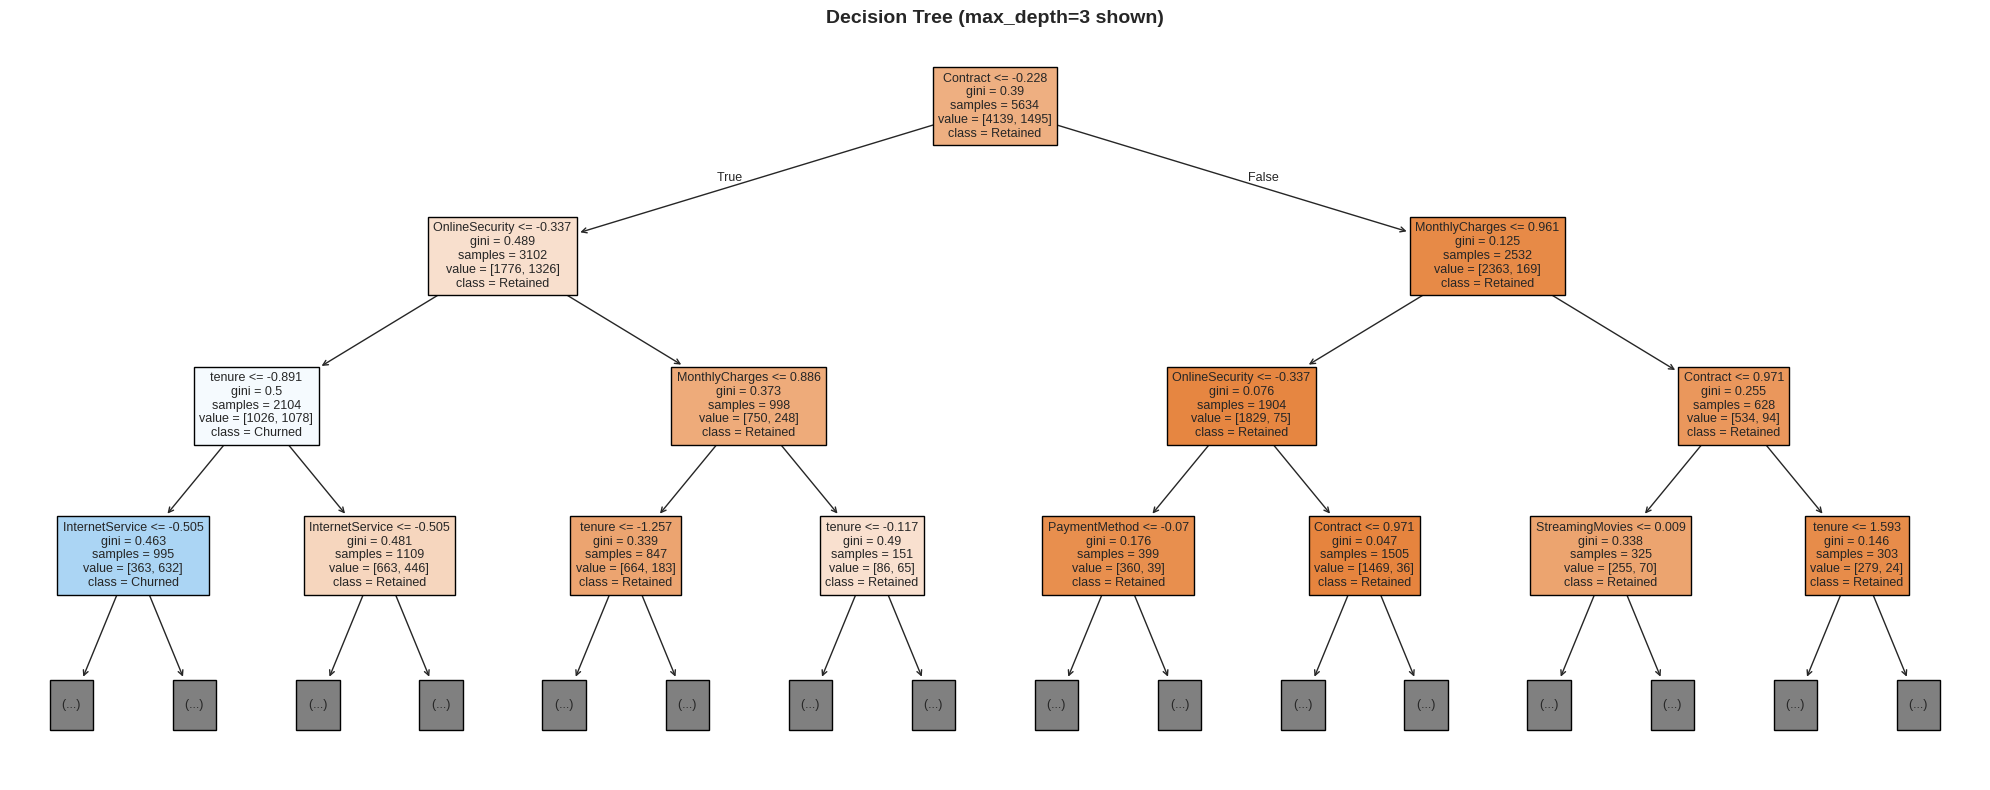

Decision tree plot saved: 03_decision_tree.png

 Churn Risk Tier Distribution:
Risk_Tier
Low       4385
Medium    1618
High      1040


In [ ]:
print("CLASSIFICATION — LOGISTIC REGRESSION & DECISION TREE")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("\n Logistic Regression")
print(classification_report(y_test, y_pred_lr, target_names=["Retained", "Churned"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")

dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("\n Decision Tree")
print(classification_report(y_test, y_pred_dt, target_names=["Retained", "Churned"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_dt):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Week 6-8: Classifier Performance", fontsize=14, fontweight="bold")


for name, probs in [("Logistic Regression", y_prob_lr), ("Decision Tree", y_prob_dt)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", lw=2)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve Comparison")
axes[0].legend()

cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Retained", "Churned"],
            yticklabels=["Retained", "Churned"])
axes[1].set_title("Decision Tree — Confusion Matrix")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("02_classification_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Classification plots saved: 02_classification_results.png")


fig, ax = plt.subplots(figsize=(20, 8))
feature_names = list(feature_df.columns)
plot_tree(dt, feature_names=feature_names, class_names=["Retained", "Churned"],
          filled=True, max_depth=3, fontsize=9, ax=ax)
ax.set_title("Decision Tree (max_depth=3 shown)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("03_decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()
print("Decision tree plot saved: 03_decision_tree.png")


df["Churn_Probability"] = lr.predict_proba(X)[:, 1]
df["Risk_Tier"] = pd.cut(df["Churn_Probability"],
                          bins=[0, 0.3, 0.6, 1.0],
                          labels=["Low", "Medium", "High"])
print("\n Churn Risk Tier Distribution:")
print(df["Risk_Tier"].value_counts().to_string())

CLUSTER ANALYSIS & RFM SEGMENTATION

 Cluster Profiles:
            Segment  count  avg_tenure  avg_monthly  avg_churn_prob  churn_rate
Cluster                                                                        
0           Premium   1891       59.49        92.92            0.13        0.14
1         High Risk   1941       13.90        83.60            0.59        0.57
2          Standard   1302       51.53        37.02            0.05        0.05
3          Standard   1909       11.22        36.64            0.22        0.22


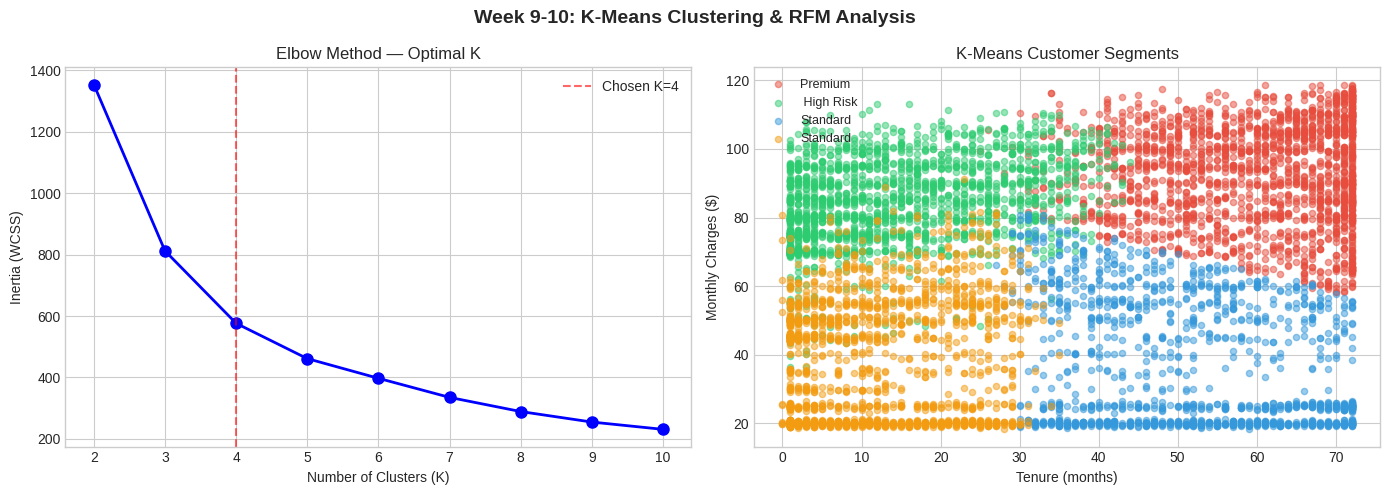

 Clustering plot saved: 04_clustering_rfm.png

 RFM Segment Distribution:
RFM_Segment
Hibernating    2180
At Risk        1808
Loyal          1593
Champions      1462


In [ ]:
print("CLUSTER ANALYSIS & RFM SEGMENTATION")

inertias = []
K_range = range(2, 11)
cluster_features = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_Probability"]
X_cluster = MinMaxScaler().fit_transform(df[cluster_features])

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Week 9-10: K-Means Clustering & RFM Analysis", fontsize=14, fontweight="bold")

axes[0].plot(K_range, inertias, "bo-", lw=2, markersize=8)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method — Optimal K")
axes[0].axvline(x=4, color="red", linestyle="--", alpha=0.6, label="Chosen K=4")
axes[0].legend()

K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df["Cluster"] = km_final.fit_predict(X_cluster)


cluster_profile = df.groupby("Cluster").agg(
    count=("customerID", "count"),
    avg_tenure=("tenure", "mean"),
    avg_monthly=("MonthlyCharges", "mean"),
    avg_churn_prob=("Churn_Probability", "mean"),
    churn_rate=("Churn_Binary", "mean"),
).round(2)

cluster_names = {
    cluster_profile["avg_churn_prob"].idxmax(): " High Risk",
    cluster_profile["avg_tenure"].idxmax():     "Loyal",
    cluster_profile["avg_monthly"].idxmax():    "Premium",
}
remaining = [c for c in range(K_FINAL) if c not in cluster_names]
for c in remaining:
    cluster_names[c] = "Standard"

df["Segment_Name"] = df["Cluster"].map(cluster_names)
cluster_profile["Segment"] = cluster_profile.index.map(cluster_names)

print("\n Cluster Profiles:")
print(cluster_profile[["Segment", "count", "avg_tenure",
                         "avg_monthly", "avg_churn_prob", "churn_rate"]].to_string())

# Scatter: tenure vs monthly charges coloured by cluster
scatter_colors = ["#e74c3c", "#2ecc71", "#3498db", "#f39c12"]
for i in range(K_FINAL):
    mask = df["Cluster"] == i
    axes[1].scatter(df.loc[mask, "tenure"],
                    df.loc[mask, "MonthlyCharges"],
                    label=cluster_names.get(i, f"Cluster {i}"),
                    alpha=0.5, s=20,
                    color=scatter_colors[i % len(scatter_colors)])
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Monthly Charges ($)")
axes[1].set_title("K-Means Customer Segments")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("04_clustering_rfm.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Clustering plot saved: 04_clustering_rfm.png")


rfm = df[["customerID", "tenure", "MonthlyCharges", "TotalCharges"]].copy()
rfm.columns = ["customerID", "Recency_proxy", "Frequency_proxy", "Monetary"]

for col in ["Recency_proxy", "Frequency_proxy", "Monetary"]:
    rfm[f"{col}_Score"] = pd.qcut(rfm[col], q=5,
                                   labels=[1, 2, 3, 4, 5],
                                   duplicates="drop")

rfm["RFM_Score"] = (rfm["Recency_proxy_Score"].astype(int) +
                    rfm["Frequency_proxy_Score"].astype(int) +
                    rfm["Monetary_Score"].astype(int))

rfm["RFM_Segment"] = pd.cut(rfm["RFM_Score"],
                              bins=[0, 6, 9, 12, 15],
                              labels=["Hibernating", "At Risk", "Loyal", "Champions"])

df = df.merge(rfm[["customerID", "RFM_Score", "RFM_Segment"]], on="customerID", how="left")

print("\n RFM Segment Distribution:")
print(df["RFM_Segment"].value_counts().to_string())


ARTIFICIAL NEURAL NETWORK (ANN)


Model: "ChurnANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 0 (0.00 B)

 ANN training complete — 13 epochs run

 ANN Results 
              precision    recall  f1-score   support

    Retained       0.84      0.87      0.85      1035
     Churned       0.60      0.53      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409

AUC-ROC: 0.8324


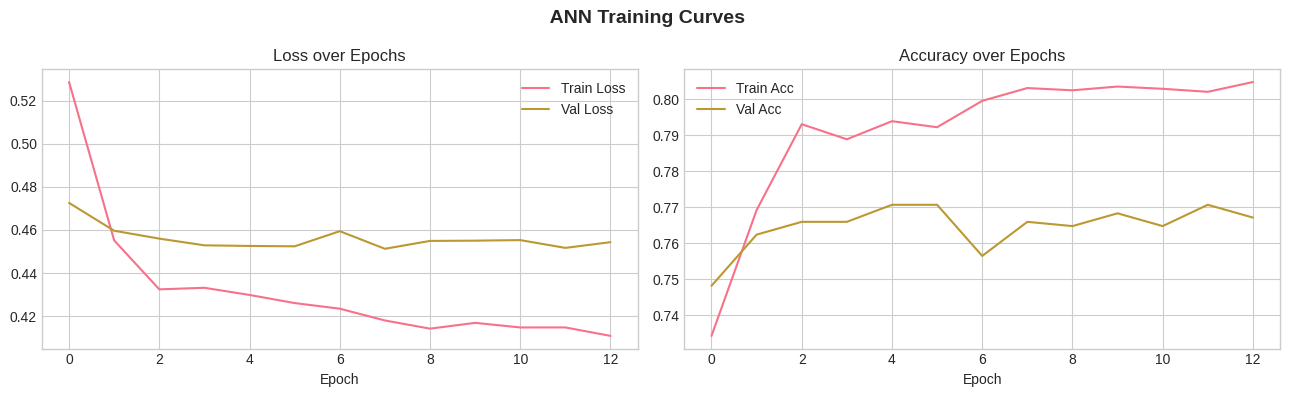

 ANN plots saved: 05_ann_training.png


In [ ]:
print("ARTIFICIAL NEURAL NETWORK (ANN)")

ann = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
], name="ChurnANN")

ann.compile(optimizer="adam",
            loss="binary_crossentropy",
            metrics=["accuracy"])

ann.summary()


history = ann.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=64,
    verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)
print(f" ANN training complete — {len(history.history['loss'])} epochs run")


y_prob_ann = ann.predict(X_test, verbose=0).ravel()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

print("\n ANN Results ")
print(classification_report(y_test, y_pred_ann, target_names=["Retained", "Churned"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_ann):.4f}")


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(" ANN Training Curves", fontsize=14, fontweight="bold")

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Acc")
axes[1].plot(history.history["val_accuracy"], label="Val Acc")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("05_ann_training.png", dpi=150, bbox_inches="tight")
plt.show()
print(" ANN plots saved: 05_ann_training.png")




In [ ]:
print("MODEL COMPARISON SUMMARY")


models = {
    "Logistic Regression": (y_pred_lr, y_prob_lr),
    "Decision Tree":       (y_pred_dt, y_prob_dt),
    "ANN":                 (y_pred_ann, y_prob_ann),
}

print(f"\n{'Model':<25} {'Accuracy':>10} {'AUC-ROC':>10} {'F1(Churn)':>12}")
print("-" * 60)
for name, (preds, probs) in models.items():
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    report = classification_report(y_test, preds, output_dict=True)
    f1_churn = report["1"]["f1-score"]
    print(f"{name:<25} {acc:>10.4f} {auc:>10.4f} {f1_churn:>12.4f}")


MODEL COMPARISON SUMMARY

Model                       Accuracy    AUC-ROC    F1(Churn)
------------------------------------------------------------
Logistic Regression           0.7999     0.8378       0.5913
Decision Tree                 0.7814     0.8257       0.6010
ANN                           0.7821     0.8324       0.5645


WEEK 12: TEXT MINING — SUPPORT TICKET SENTIMENT


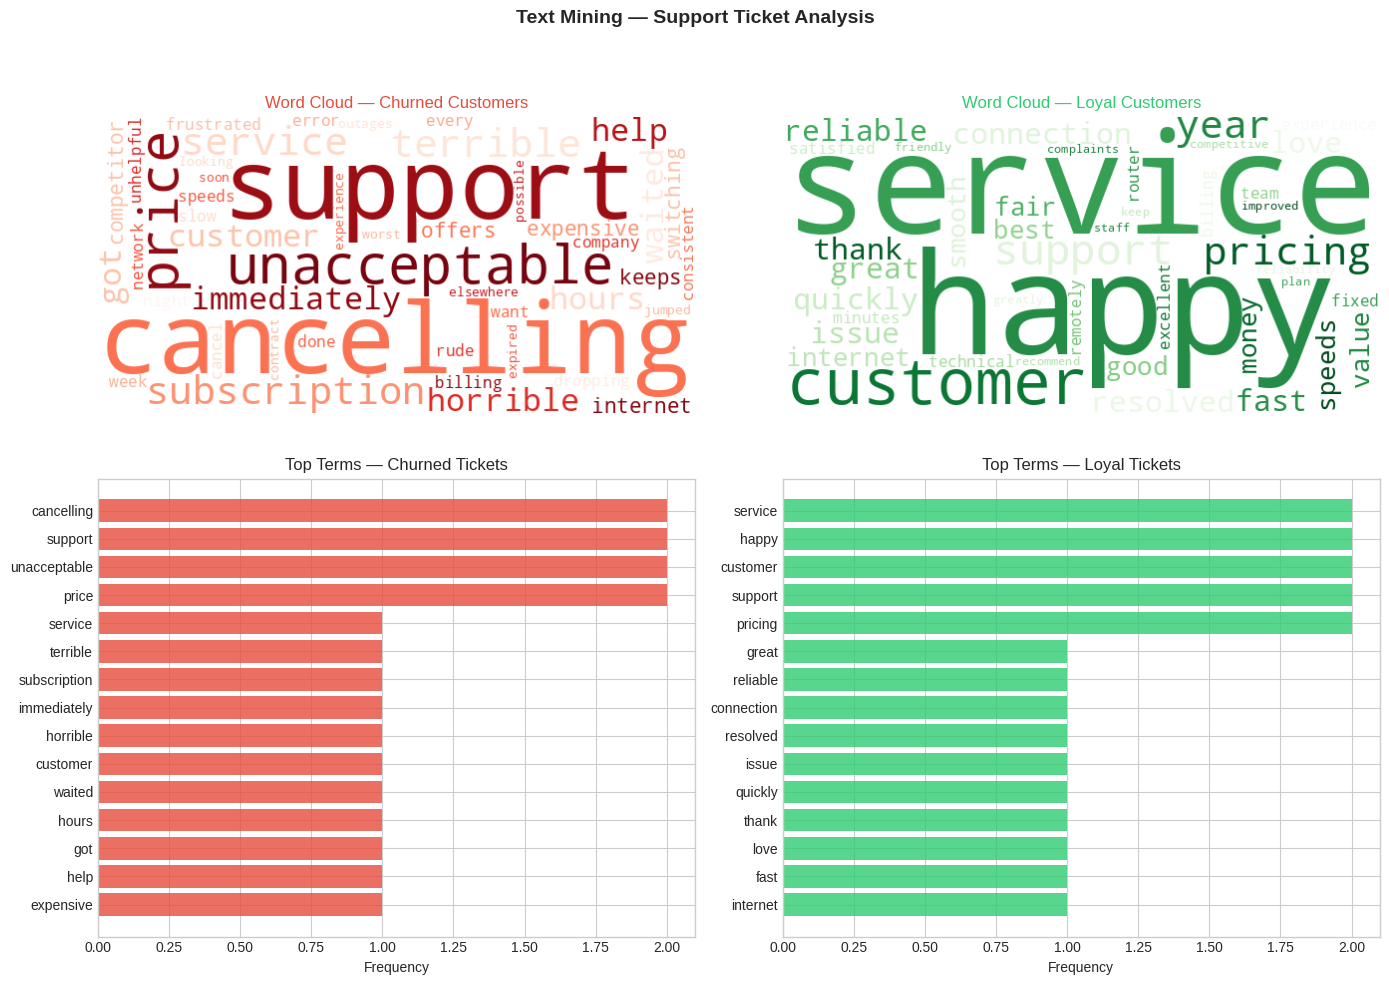

 Text mining plots saved: 06_text_mining.png
Support ticket keyword flags added to main dataset


In [ ]:
print("WEEK 12: TEXT MINING — SUPPORT TICKET SENTIMENT")

np.random.seed(99)
churn_tickets = [
    "The service is terrible, cancelling my subscription immediately",
    "Horrible customer support, I waited 2 hours and got no help",
    "Too expensive for what it offers, switching to competitor",
    "Internet keeps dropping every night, very frustrated",
    "Billing error again! I am done with this company",
    "Slow speeds all week, unacceptable for the price",
    "Support was rude and unhelpful, I want to cancel",
    "Consistent network outages, this is unacceptable",
    "My contract expired and the price jumped, looking elsewhere",
    "Worst experience ever, cancelling as soon as possible",
]
loyal_tickets = [
    "Great service and reliable connection, very happy customer",
    "Customer support resolved my issue quickly, thank you",
    "Love the fast internet speeds, best I have had",
    "Fair pricing and good value for money",
    "Smooth experience from sign-up to billing, very satisfied",
    "Technical team fixed my router remotely in minutes",
    "Excellent reliability over 3 years, would recommend",
    "Competitive pricing and friendly support staff",
    "Service has improved greatly this year, keep it up",
    "Happy with my plan, no complaints at all",
]

all_tickets = (
    [(t, 1) for t in churn_tickets] +
    [(t, 0) for t in loyal_tickets]
)
df_tickets = pd.DataFrame(all_tickets, columns=["text", "churned"])

stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return tokens

df_tickets["tokens"] = df_tickets["text"].apply(preprocess_text)

churn_words = [w for tokens, c in zip(df_tickets["tokens"], df_tickets["churned"])
               if c == 1 for w in tokens]
loyal_words = [w for tokens, c in zip(df_tickets["tokens"], df_tickets["churned"])
               if c == 0 for w in tokens]

churn_freq = Counter(churn_words).most_common(15)
loyal_freq = Counter(loyal_words).most_common(15)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Text Mining — Support Ticket Analysis", fontsize=14, fontweight="bold")

churn_text = " ".join(churn_words)
wc_churn = WordCloud(width=600, height=300, background_color="white",
                     colormap="Reds", max_words=50).generate(churn_text)
axes[0, 0].imshow(wc_churn, interpolation="bilinear")
axes[0, 0].axis("off")
axes[0, 0].set_title("Word Cloud — Churned Customers", color="#e74c3c")


loyal_text = " ".join(loyal_words)
wc_loyal = WordCloud(width=600, height=300, background_color="white",
                     colormap="Greens", max_words=50).generate(loyal_text)
axes[0, 1].imshow(wc_loyal, interpolation="bilinear")
axes[0, 1].axis("off")
axes[0, 1].set_title("Word Cloud — Loyal Customers", color="#2ecc71")


words_c, freqs_c = zip(*churn_freq)
axes[1, 0].barh(words_c[::-1], freqs_c[::-1], color="#e74c3c", alpha=0.8)
axes[1, 0].set_title("Top Terms — Churned Tickets")
axes[1, 0].set_xlabel("Frequency")


words_l, freqs_l = zip(*loyal_freq)
axes[1, 1].barh(words_l[::-1], freqs_l[::-1], color="#2ecc71", alpha=0.8)
axes[1, 1].set_title("Top Terms — Loyal Tickets")
axes[1, 1].set_xlabel("Frequency")

plt.tight_layout()
plt.savefig("06_text_mining.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Text mining plots saved: 06_text_mining.png")

CHURN_KEYWORDS = {"cancel", "terrible", "expensive", "frustrated", "horrible",
                  "slow", "dropping", "rude", "error", "outage"}

def flag_risk_keywords(text):
    tokens = set(word_tokenize(str(text).lower()))
    return int(bool(tokens & CHURN_KEYWORDS))

df["support_risk_flag"] = 0
print("Support ticket keyword flags added to main dataset")